# Analyse SHAP values only for FN / FP women --> this doesnt work like this!!

In [7]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import shap
import pickle
import sys
sys.path.append("../")
PATH = "/home/WUR/katz001/PROJECTS/myaReg_gender"

from func_preprocess import read_data, subset_wo_missigness, remove_NA, parseVariables, clean_data, impute_scale 

In [8]:
def prepare(data):
    #######
    var_subset_analysis =  False #['testergebnisdekrement_rb']#, 'lrp4antikoerper_rb', 'histologie_sprb']  # False 
    #######
    if var_subset_analysis: 
        data = subset_wo_missigness(data, var_subset_analysis)
    data_clean = remove_NA(data, cutoff_perc=35)

    ''' 
    3. OPTIONAL. remove the ones we dont like
    '''
    vars2remove = ["age", "age_bei_diagnose",
                "scoreqol_neu", "chronicfatigue_neu", "aktueller_mgfa_score", ## too many scores otherwise
                "seelischesbefinden_neu",
                "zn_myasthener_krise_jn",
                "seronegativ",
                "kortison_sprb", "azathioprin_sprb", "methotrexatfolsauure_sprb", "mycophenolatmofetil_sprb",       ### weil ee_immuntherapie_grrb
                "eculizumab_sprb", "rituximab_sprb",               ## weil eskalationstherapiebeitherapierefraktaerermyasthenie_grrb
                "plasmapherese_sprb", "immunadsorption_sprb", "ivig_sprb",       ## weil exazerbationstherapie_grrb
                "okulaer", "bulbaer", "generalisiertemuskelschwaeche" ### weil correlated
                ]
    data_clean_parsed = parseVariables(data_clean, vars2remove)

    ''' 
    4. clean variables; e.g. MGFA classification
    '''
    data_clean_parsed = clean_data(data_clean_parsed)

    ''' 
    5. impute and scale
    `df_imputedScaled` = scaled dataset for clustering algorithm
    `df_reverseTransform` = unscaled "normal" values for plotting - makes it easier to interpret plot
    '''
    df_imputedScaled, df_reverseTransform = impute_scale(data_clean_parsed, ohe_yn=False)

    df_imputedScaled.index = data_clean_parsed.index
    df_reverseTransform.index = data_clean_parsed.index

    return df_imputedScaled, df_reverseTransform

In [9]:
### Read dataset and split
PATH_base = "/home/WUR/katz001/PROJECTS/myaReg_gender"

''' 
Prepare data --> change here for different setups!
'''
target = "gender"
percentBoruta = 80
CV_repeats = 30

''' 
Select features
'''
varFolder = "CV_v3_mgfaRecoded" #_mgfaRecoded"
var = f"{target}_bootstrapped_iterativeBoruta_{percentBoruta}perc"
varPath = f"{PATH_base}/results/10_featureSelection/{varFolder}/{var}.txt"
sel_variables = pd.read_csv(varPath, header=None)[0].tolist()

# varFolder = "manual_selection" #_mgfaRecoded"
# var = f"allVars_mgfaRecoded"
# varPath = f"{PATH_base}/results/10_featureSelection/{varFolder}/{var}.txt"
# sel_variables = pd.read_csv(varPath, header=None)[0].tolist()

''' 
Define paths
'''
resultsPath = f"{PATH_base}/results/30_predictions/{varFolder}/{var}/SHAP"
os.makedirs(resultsPath, exist_ok=True)
figurePath = f"{PATH_base}/figures/{varFolder}/{var}"
os.makedirs(figurePath, exist_ok=True)


''' 
get data
'''
# varFolder = "CV_v3_mgfaRecoded" #_mgfaRecoded"
# var = f"{target}_bootstrapped_iterativeBoruta_{percentBoruta}perc"
dataPath = f"{PATH_base}/results/30_predictions/{varFolder}/{var}/women_FN_TP"
df_fn = pd.read_csv(f"{dataPath}/women_fn.csv")
df_tp = pd.read_csv(f"{dataPath}/women_tp.csv")


''' Get data '''
allData_imputedScaled, allData_reverseTransform = prepare(read_data(PATH_base, FILENAME="all_data_edited_v3_mgfaRecoded_inverse"))
allData_reverseTransform = allData_reverseTransform.loc[:, sel_variables]

''' Load SHAP'''
with open(f"{resultsPath}/repeatedDCV_{CV_repeats}iter_shap.p", "rb") as f:
    shap_values_per_cv = pickle.load(f)

''' Load predicted probabilities of label 1'''
with open(f"{resultsPath}/repeatedDCV_{CV_repeats}iter_predProb.p", "rb") as f:
    predProb_per_cv = pickle.load(f)

''' Load labels'''
pid = pd.read_csv(f"{resultsPath}/pid.csv", index_col=0, header=None)
pid.index = pid[1]
pid[1] = range(0, len(pid))

''' 
Average SHAP 

Establish lists to keep average Shap values, their Stds, and their min and max
'''

average_shap_values, stds, ranges = [],[],[]

for i in range(0,len(allData_reverseTransform)):
    df_per_obs = pd.DataFrame.from_dict(shap_values_per_cv[i]) # Get all SHAP values for sample number i
    # Get relevant statistics for every sample 
    average_shap_values.append(df_per_obs.mean(axis=1).values) 
    stds.append(df_per_obs.std(axis=1).values)
    ranges.append(df_per_obs.max(axis=1).values-df_per_obs.min(axis=1).values)






LOADING DATA


REMOVING MISSINGNESS (cutoff=35%)
Keeping 36/41 variables
Discarded: ['testergebnisdekrement_rb', 'testergebnispyridostigmin_rb', 'lrp4antikoerper_rb', 'histologie_sprb', 'scoreqmg_neu']


REMOVING BIASING / UNWANTED VARIABLES
Discarded: ['zn_myasthener_krise_jn', 'aktueller_mgfa_score', 'okulaer', 'bulbaer', 'generalisiertemuskelschwaeche', 'kortison_sprb', 'azathioprin_sprb', 'methotrexatfolsauure_sprb', 'mycophenolatmofetil_sprb', 'eculizumab_sprb', 'rituximab_sprb', 'plasmapherese_sprb', 'immunadsorption_sprb', 'ivig_sprb', 'age', 'age_bei_diagnose', 'seronegativ', 'scoreqol_neu', 'chronicfatigue_neu', 'seelischesbefinden_neu']
(1814, 16)


CLEANING DATASET


IMPUTING & SCALING


## Summary Plot for SHAP

Text(0.5, 1.0, 'all patients')

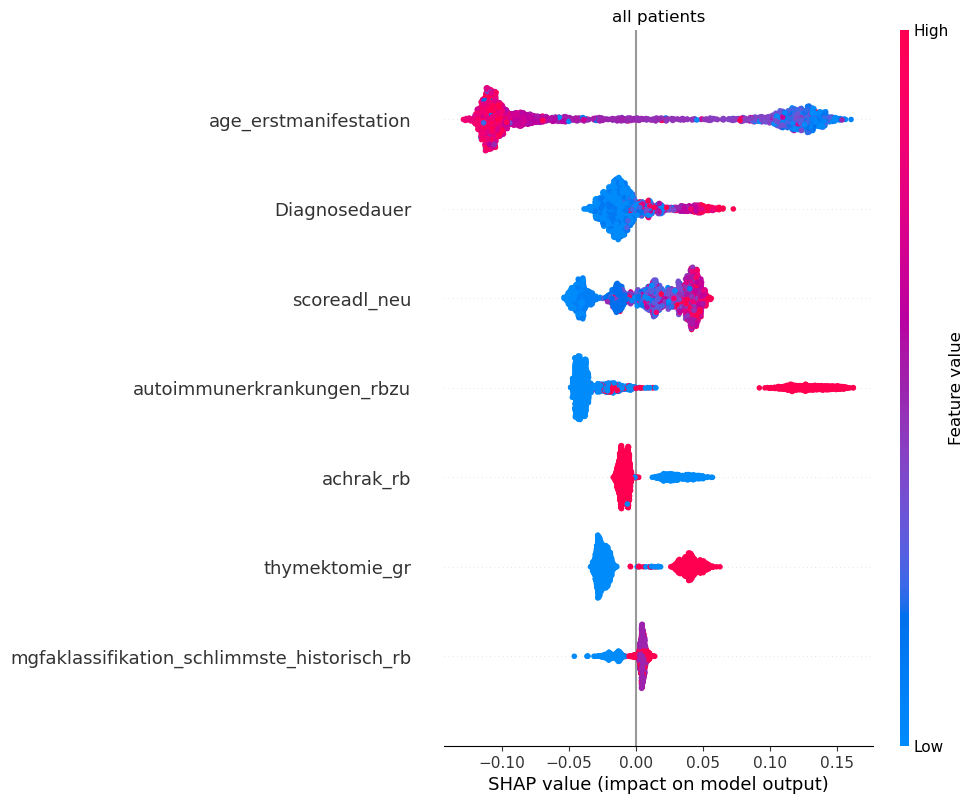

In [11]:
shap.summary_plot(np.array(average_shap_values), allData_reverseTransform, show = False, sort=False, plot_size=(10.0,8.0))
plt.title(f'all patients')

In [ ]:
women_fn = pd.read_csv("/home/WUR/katz001/PROJECTS/myaReg_gender/results/30_predictions/CV_v3_mgfaRecoded/gender_bootstrapped_iterativeBoruta_80perc/women_FN_TP/women_fn.csv")["pid"]
women_tp = pd.read_csv("/home/WUR/katz001/PROJECTS/myaReg_gender/results/30_predictions/CV_v3_mgfaRecoded/gender_bootstrapped_iterativeBoruta_80perc/women_FN_TP/women_tp.csv")["pid"]
print(women_tp.shape)

(745,)


Text(0.5, 1.0, 'FN women')

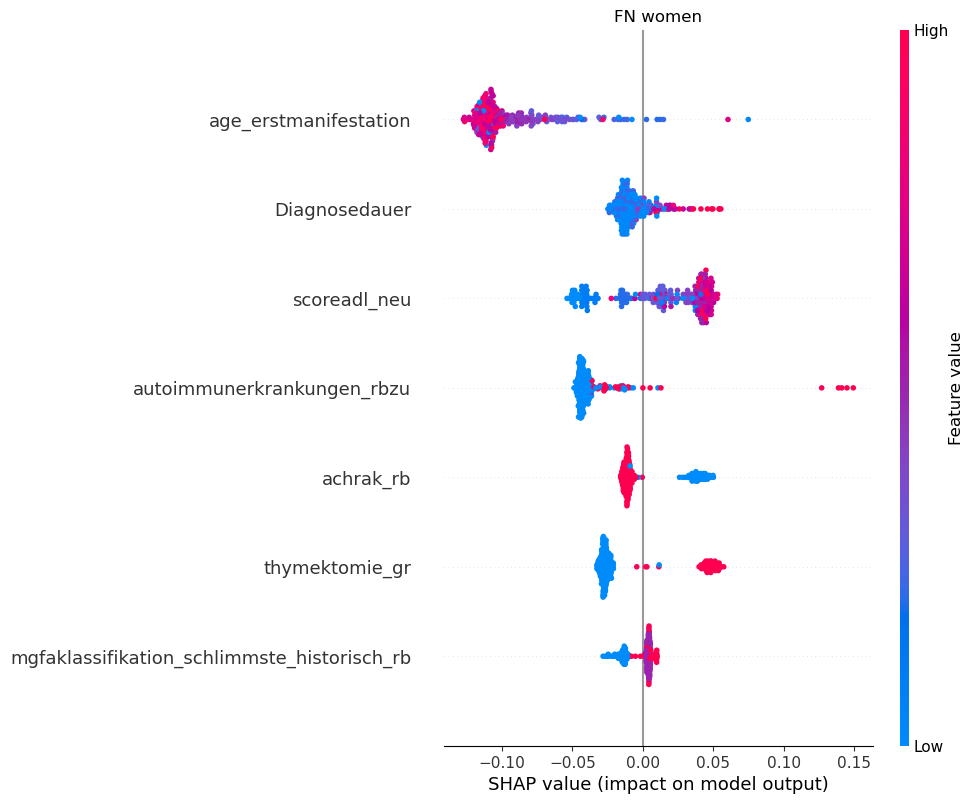

In [22]:
findRowNum = allData_reverseTransform.copy()
findRowNum["row"] = range(len(findRowNum))

row_fn = findRowNum.loc[women_fn, "row"].tolist()

shap.summary_plot(np.array(average_shap_values)[row_fn], allData_reverseTransform.iloc[row_fn,:], show = False, sort=False, plot_size=(10.0,8.0))
plt.title(f'FN women')

Text(0.5, 1.0, 'TP women')

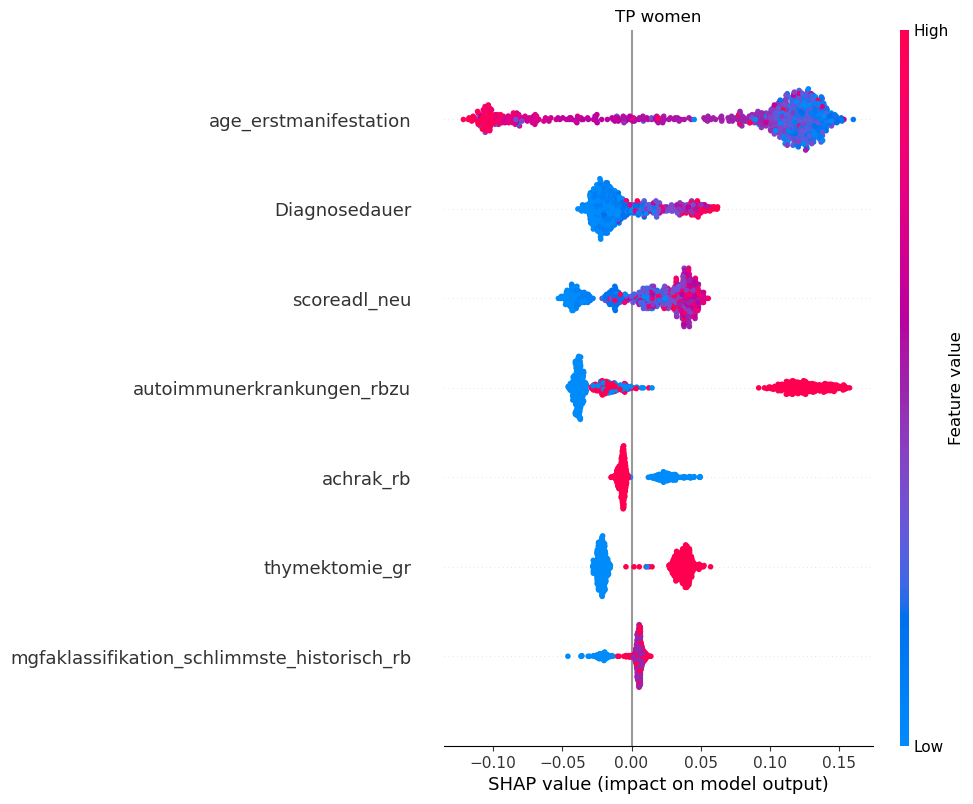

In [23]:
findRowNum = allData_reverseTransform.copy()
findRowNum["row"] = range(len(findRowNum))

row_tp = findRowNum.loc[women_tp, "row"].tolist()

shap.summary_plot(np.array(average_shap_values)[row_tp], allData_reverseTransform.iloc[row_tp,:], show = False, sort=False, plot_size=(10.0,8.0))
plt.title(f'TP women')